### Import data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [1]:
import pandas as pd
import numpy as np

inf = pd.read_csv('../data/inf.csv', header=0, index_col=None)
occ = pd.read_csv('../data/occupancy.csv', header=0, index_col=0)
duration = pd.read_csv('../data/duration.csv', header=0, index_col=0)
volume = pd.read_csv('../data/volume.csv', header=0, index_col=0)
e_price = pd.read_csv('../data/e_price.csv', index_col=0, header=0).values
s_price = pd.read_csv('../data/s_price.csv', index_col=0, header=0).values
adj = pd.read_csv('../data/adj.csv', header=0, index_col=None)
weather = pd.read_csv('../data/weather_central.csv',header=0,index_col='time')

In [2]:
#STUB - import adj and preprocess:
import torch
adj = np.array(adj)
adj_dense  = torch.Tensor(adj)
adj_dense.shape[0]

275

### Process data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [3]:
occ

,102,104,105,106,107,108,109,110,111,115,...,1156,1159,1162,1163,1164,1166,1167,1168,1172,1173
time,,,,,,,,,,,,,,,,,,,,,
9/1/2022 0:00,17,1.0,15.0,54.0,23.0,13,11.0,6.0,20.0,3.0,...,10.0,31.0,9,2.0,45.0,26.0,183,17.0,2,10.0
9/1/2022 1:00,16,1.0,19.0,50.0,25.0,13,7.0,12.0,19.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,174,12.0,2,9.0
9/1/2022 2:00,16,1.0,20.0,44.0,24.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,196,13.0,2,12.0
9/1/2022 3:00,16,1.0,20.0,44.0,22.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,187,13.0,2,13.0
9/1/2022 4:00,17,1.0,20.0,50.0,24.0,13,8.0,12.0,20.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,167,11.0,2,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/28/2023 19:00,10,2.0,15.0,43.0,13.0,12,6.0,9.0,12.0,2.0,...,4.0,37.0,2,5.0,33.0,22.0,145,8.0,3,9.0
2/28/2023 20:00,13,2.0,16.0,43.0,16.0,14,8.0,9.0,13.0,2.0,...,4.0,38.0,3,5.0,30.0,23.0,171,10.0,4,10.0
2/28/2023 21:00,14,2.0,16.0,44.0,18.0,13,7.0,10.0,14.0,2.0,...,3.0,36.0,7,5.0,34.0,27.0,183,10.0,4,10.0


### Build Tensor data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [4]:
import torch
import numpy as np

def build_tensor(occ_df, price_np):
    occ_np = occ_df.to_numpy(dtype=np.float32)
    price_np = np.asarray(price_np, dtype=np.float32)

    occ_np = occ_np[:, :, None]
    price_np = price_np[:, :, None]

    T_np = weather["T"].to_numpy(dtype=np.float32)[:, None, None]
    T_np = np.repeat(T_np, occ_np.shape[1], axis=1)

    x = np.concatenate([occ_np, price_np, T_np], axis=2)

    return torch.tensor(x, dtype=torch.float32)

In [5]:
def build_seq_dataset(data, seq_len=12, pred_len=1):
    # data: (T, nodes, features)
    X = []
    y = []

    T = data.shape[0] # data input có shape là (4434,275,3). Lấy shape [0] là lấy 4434

    for t in range(T - seq_len - pred_len + 1):
        x_seq = data[t : t + seq_len]              # (seq, nodes, features)
        y_target = data[t + seq_len, :, 0]         # occupancy next step: (nodes,)

        X.append(x_seq)
        y.append(y_target)

    X = torch.stack(X)   # (samples, seq, nodes, features)
    y = torch.stack(y)   # (samples, nodes)

    # đổi sang (samples, nodes, seq, features)
    X = X.permute(0, 2, 1, 3)

    return X, y

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [7]:
import os
import random
import numpy as np
import torch

def set_seed(seed=42):
    # Python built-in random module
    random.seed(seed)
    
    # NumPy library
    np.random.seed(seed)
    
    # PyTorch CPU operations
    torch.manual_seed(seed)
    
    # PyTorch GPU operations (if using CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU
    
    # CuDNN backends (ensures deterministic algorithms)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)

# Execute the setup
set_seed(42)

#### 🌸 Pytorch tensor data conv1d

Input data of Conv1D: [Batch, Channels, Length]
Here I will set Batch as Nodes, Channels as occupancy feature, Length as 12 hour timestep

In [8]:
occ_numpy = occ.to_numpy( dtype = np.float32)

In [9]:
occ_tensor_conv1d = torch.tensor(occ_numpy ,dtype=torch.float32)
occ_tensor_conv1d.shape

torch.Size([4344, 275])

In [10]:
train_raw_conv1d = occ_tensor_conv1d[:3040]
val_raw_conv1d   = occ_tensor_conv1d[3040:3692]
test_raw_conv1d  = occ_tensor_conv1d[3692:]

In [11]:
def build_seq_data_conv1d(data, seq_len=12, pred_len=1):
    # data: (T, nodes)
    X = []
    y = []

    T = data.shape[1] # data input có shape là (4434,275). Lấy shape [1] là lấy 275

    for t in range(T - seq_len - pred_len + 1):
        x_seq = data[t : t + seq_len]              # (seq, nodes, features)
        y_target = data[t + seq_len, :]         # occupancy next step: (nodes,)

        X.append(x_seq)
        y.append(y_target)

    X = torch.stack(X)   # (samples, seq, nodes, features)
    y = torch.stack(y)   # (samples, nodes)

    # đổi sang (samples, nodes, seq)
    X = X.permute(0, 2, 1)

    return X, y

In [12]:
X_train_conv1d, y_train_conv1d = build_seq_data_conv1d(train_raw_conv1d, seq_len=12)

print(X_train_conv1d.shape)
print(y_train_conv1d.shape)

torch.Size([263, 275, 12])
torch.Size([263, 275])


In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

# X_train: [num_samples, N, T, F]
# y_train: [num_samples, N]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

num_samples, N, T = X_train_conv1d.shape

X_train_conv1d_scaled = x_scaler.fit_transform(X_train_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_train_conv1d_scaled = y_scaler.fit_transform(y_train_conv1d.reshape(-1, 1)).reshape(y_train_conv1d.shape)

X_train_conv1d_scaled = torch.tensor(X_train_conv1d_scaled, dtype=torch.float32)
y_train_conv1d_scaled = torch.tensor(y_train_conv1d_scaled, dtype=torch.float32)

train_data_scale_conv1d = TensorDataset(X_train_conv1d_scaled,y_train_conv1d_scaled)

train_data_scale_conv1d_loader = DataLoader(train_data_scale_conv1d,batch_size=32,shuffle=True)

In [14]:
X_train_conv1d, y_train_conv1d = build_seq_data_conv1d(train_raw_conv1d, seq_len=12)

# print(X_train_conv1d)
# print(y_train_conv1d.shape)

In [15]:
train_conv1d = TensorDataset(X_train_conv1d, y_train_conv1d)
train_conv1d_loader = DataLoader(train_conv1d, batch_size = 32, shuffle = False)
print(type(train_conv1d_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [16]:
X_test_conv1d, y_test_conv1d = build_seq_data_conv1d(test_raw_conv1d, seq_len=12)

# print(X_train_conv1d)
# print(y_train_conv1d.shape)

In [17]:
num_samples, N, T = X_test_conv1d.shape

X_test_conv1d_scaled = x_scaler.fit_transform(X_test_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_test_conv1d_scaled = y_scaler.fit_transform(y_test_conv1d.reshape(-1, 1)).reshape(y_test_conv1d.shape)

X_test_conv1d_scaled = torch.tensor(X_test_conv1d_scaled, dtype=torch.float32)
y_test_conv1d_scaled = torch.tensor(y_test_conv1d_scaled, dtype=torch.float32)

test_data_scale_conv1d = TensorDataset(X_test_conv1d_scaled,y_test_conv1d_scaled)

test_data_scale_conv1d_loader = DataLoader(test_data_scale_conv1d,batch_size=32,shuffle=False)

In [18]:
X_val_conv1d, y_val_conv1d = build_seq_data_conv1d(val_raw_conv1d, seq_len=12)

print(X_train_conv1d.shape)
# print(y_train_conv1d.shape)

torch.Size([263, 275, 12])


In [19]:
num_samples, N, T = X_val_conv1d.shape

X_val_conv1d_scaled = x_scaler.fit_transform(X_val_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_val_conv1d_scaled = y_scaler.fit_transform(y_val_conv1d.reshape(-1, 1)).reshape(y_val_conv1d.shape)

X_val_conv1d_scaled = torch.tensor(X_val_conv1d_scaled, dtype=torch.float32)
y_val_conv1d_scaled = torch.tensor(y_val_conv1d_scaled, dtype=torch.float32)

val_data_scale_conv1d = TensorDataset(X_val_conv1d_scaled,y_val_conv1d_scaled)

val_data_scale_conv1d_loader = DataLoader(val_data_scale_conv1d,batch_size=32,shuffle=False)

In [20]:
val_conv1d = TensorDataset(X_val_conv1d, y_val_conv1d)
val_conv1d_loader = DataLoader(val_conv1d, batch_size = 32, shuffle = False)
print(type(val_conv1d_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [21]:
for x,y in train_data_scale_conv1d_loader:
    print (x.shape)
    print(y.shape)
    break

torch.Size([32, 275, 12])
torch.Size([32, 275])


### Models

In [22]:
class Lstm(nn.Module):
    def __init__(self, seq, node=275):
        super(Lstm, self).__init__()
        self.nodes = node
        self.seq_len = seq
        # self.encoder = nn.Linear(1,1)# input.shape: [batch, channel, length]
        self.lstm_hidden_dim = 64
        self.lstm = nn.LSTM(input_size=1, hidden_size=self.lstm_hidden_dim, num_layers=2,
                            batch_first=True)
        self.linear = nn.Linear(seq * self.lstm_hidden_dim, 1)

    def forward(self, x, extra_feat=None):  # occ.shape = [batch, node, seq]
        bs = x.shape[0]
        x = x.unsqueeze(-1)
        x = x.view(bs * self.nodes, self.seq_len,1)

        lstm_out, _ = self.lstm(x)  # lstm_out shape: [batch_size * node, seq_len, lstm_hidden_dim]
        lstm_out = lstm_out.reshape(bs, self.nodes, self.seq_len * self.lstm_hidden_dim)
        x = self.linear(lstm_out)
        x = torch.squeeze(x)
        return x

In [23]:
model_lstm = Lstm(seq=12)

In [24]:
class GCN_LSTM(nn.Module):
    def __init__(self,sequence, adj_dense, gcn_out, nodes = 275, output_dimension = 1, hidden_dimension = 32):
        super().__init__()
        self.nodes = nodes
        self.sequence = sequence
        self.output_dimension = output_dimension
        self.hidden_dimension = hidden_dimension
        self.gcn_out = gcn_out
        self.activation_function = nn.ReLU()
        self.encoder = nn.Conv1d(self.nodes, self.nodes, 1)
        
        # Calculate A_delta matrix (normalized adjacency)
        deg = torch.sum(adj_dense, dim=0)
        deg = torch.diag(deg)
        deg_delta = torch.linalg.inv(torch.sqrt(deg))
        a_delta = torch.matmul(torch.matmul(deg_delta, adj_dense),  deg_delta)
        self.A = a_delta
        
        #Define LSTM layers:
        self.lstm_hidden_dim = 64
        self.lstm = nn.LSTM(input_size = 1, hidden_size = self.lstm_hidden_dim, num_layers = 2, batch_first = True)
        # self.linear = nn.Linear(sequence*self.lstm_hidden_dim, 1)
        
        #Define GCN layers:
        self.gcn_layer_list = nn.ModuleList()
        self.gcn_layer_list.append(nn.Linear(self.sequence, self.hidden_dimension))
        self.gcn_layer_list.append(nn.Linear(self.hidden_dimension, self.hidden_dimension))
        
        self.decoder = nn.Linear(sequence + self.gcn_out + self.lstm_hidden_dim, 1) #giữ lại data input
        
        
    def forward(self,x):
        x = self.encoder(x)
        bs = x.shape[0]
        x = x.unsqueeze(-1)
        x_lstm = x.view(bs*self.nodes, self.sequence,1)
        x = x.squeeze(-1)
        #Proceed all timesteps with LSTM:
        lstm_out, _ = self.lstm(x_lstm)
        lstm_out = lstm_out.view(bs, self.nodes, self.sequence, self.lstm_hidden_dim)
        
        #proceed thru GCN layers:
        gcn_out = x.view(bs,self.nodes,self.sequence)
        for gcn_layer in self.gcn_layer_list:
            gcn_out = gcn_layer(gcn_out)
            gcn_out = torch.matmul(self.A, gcn_out)
            gcn_out = self.activation_function(gcn_out)
        
        #Concatenate outputs:
        
        combined_output = torch.cat((x,gcn_out,lstm_out[:,:,-1,:]), dim = -1)
        x = self.decoder(combined_output)
        x = x.squeeze(-1)
        
        return x
      

In [25]:
gcn_lstm = GCN_LSTM(sequence = 12, adj_dense = adj_dense,gcn_out = 32)

In [26]:
lstm = nn.LSTM(input_size = 1, hidden_size = 16, num_layers = 2, batch_first = True)
encoder = nn.Conv1d(275, 275, 1)

In [27]:
train_raw_conv1d

tensor([[17.,  1., 15.,  ..., 17.,  2., 10.],
        [16.,  1., 19.,  ..., 12.,  2.,  9.],
        [16.,  1., 20.,  ..., 13.,  2., 12.],
        ...,
        [10.,  1., 17.,  ...,  5.,  6.,  8.],
        [ 9.,  1., 18.,  ...,  6.,  6.,  8.],
        [ 9.,  1., 18.,  ...,  6.,  5.,  7.]])

In [28]:
x,y = next(iter(train_data_scale_conv1d_loader))
x.shape



torch.Size([32, 275, 12])

In [29]:
x1 = x.unsqueeze(-1)
x1.shape

torch.Size([32, 275, 12, 1])

In [30]:
out = encoder(x)

print(out[0,0,:]) #batch, nodes, seq
out.shape

tensor([-0.1200, -0.1923, -0.3082,  0.0353, -0.2877, -0.1908, -0.1526, -0.2527,
        -0.1916,  0.0108, -0.0018,  0.0232], grad_fn=<SelectBackward0>)


torch.Size([32, 275, 12])

In [31]:
out.size(0)

32

In [32]:
out1 = out.view(32*275, 12,1) #LSTM expects (batch, seq, feature)
out1.shape

torch.Size([8800, 12, 1])

In [33]:
out2,_ = lstm(out1)
out2 = out2.view(32,275,12, 16)


### Run models LSTM

In [34]:
import torch.nn.functional as F

def metric(pred, target):

    mae = F.l1_loss(pred, target)

    mse = F.mse_loss(pred, target)

    rmse = torch.sqrt(mse)

    mape = (torch.mean(torch.abs((target - pred) / (target + 1e-8))) * 100)

    return mae.item(), rmse.item(), mape.item()

In [35]:
%%time
optimizer = torch.optim.Adam(model_lstm.parameters(),lr=1e-3)
train_loss_list_lstm = []
val_loss_list_lstm = []

for epoch in range(100):
    model_lstm.train()
    train_loss = 0

    for x, y in train_data_scale_conv1d_loader:
        pred = model_lstm(x)
        loss = F.mse_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_data_scale_conv1d_loader)
    train_loss_list_lstm.append(train_loss)
    
    # Validation after each epoch
    model_lstm.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_val, y_val in val_data_scale_conv1d_loader:
            pred_val = model_lstm(x_val)
            loss_val = F.mse_loss(pred_val, y_val)
            val_loss += loss_val.item()
            
    val_loss /= len(val_data_scale_conv1d_loader)
    val_loss_list_lstm.append(val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train MSE={train_loss:.4f} | Val MSE={val_loss:.4f}")

Epoch 01 | Train MSE=0.9110 | Val MSE=0.7470
Epoch 02 | Train MSE=0.4717 | Val MSE=0.2538
Epoch 03 | Train MSE=0.2545 | Val MSE=0.2347
Epoch 04 | Train MSE=0.2418 | Val MSE=0.2331
Epoch 05 | Train MSE=0.2005 | Val MSE=0.2204
Epoch 06 | Train MSE=0.1901 | Val MSE=0.2081
Epoch 07 | Train MSE=0.1885 | Val MSE=0.1982
Epoch 08 | Train MSE=0.1792 | Val MSE=0.1847
Epoch 09 | Train MSE=0.1558 | Val MSE=0.1768
Epoch 10 | Train MSE=0.1588 | Val MSE=0.1616
Epoch 11 | Train MSE=0.1448 | Val MSE=0.1470
Epoch 12 | Train MSE=0.1251 | Val MSE=0.1327
Epoch 13 | Train MSE=0.1121 | Val MSE=0.1281
Epoch 14 | Train MSE=0.1054 | Val MSE=0.1088
Epoch 15 | Train MSE=0.1091 | Val MSE=0.1039
Epoch 16 | Train MSE=0.0921 | Val MSE=0.0937
Epoch 17 | Train MSE=0.0899 | Val MSE=0.0871
Epoch 18 | Train MSE=0.0885 | Val MSE=0.0822
Epoch 19 | Train MSE=0.0828 | Val MSE=0.0775
Epoch 20 | Train MSE=0.0810 | Val MSE=0.0707
Epoch 21 | Train MSE=0.0719 | Val MSE=0.0656
Epoch 22 | Train MSE=0.0721 | Val MSE=0.0622
Epoch 23 |

In [36]:
model_lstm.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for x_val, y_val in val_data_scale_conv1d_loader:
        pred_val = model_lstm(x_val)

        y_true_list.append(y_val.detach().cpu().numpy())
        y_pred_list.append(pred_val.detach().cpu().numpy())

# Gộp list thành numpy array
y_true_scaled = np.concatenate(y_true_list, axis=0)
y_pred_scaled = np.concatenate(y_pred_list, axis=0)

# Lưu lại shape gốc
y_true_shape = y_true_scaled.shape
y_pred_shape = y_pred_scaled.shape

# Inverse scale
y_original = y_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(y_true_shape)

pred_original = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_shape)

# Làm phẳng để tính RMSE
y_original_flat = y_original.reshape(-1)
pred_original_flat = pred_original.reshape(-1)

rmse = np.sqrt(np.mean((pred_original_flat - y_original_flat) ** 2))

print(f"Final RMSE = {rmse:.4f}")

Final RMSE = 3.6652


In [37]:
import matplotlib.pyplot as plt

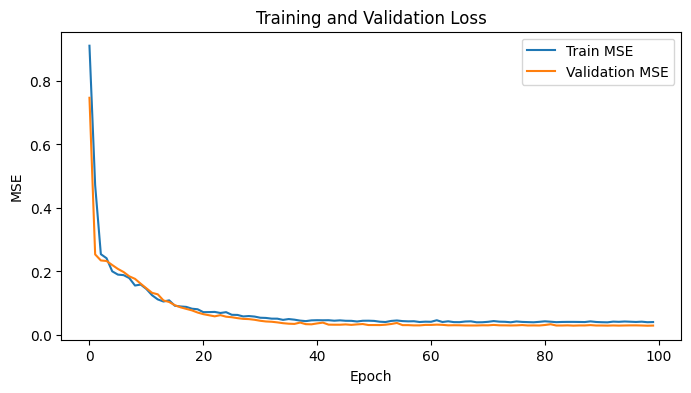

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_list_lstm, label="Train MSE")
plt.plot(val_loss_list_lstm, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Run models GCN_LSTM

In [39]:
import torch.nn.functional as F

optimizer = torch.optim.Adam(gcn_lstm.parameters(),lr=1e-3)
train_loss_list = []
val_loss_list = []

for epoch in range(100):
    gcn_lstm.train()
    train_loss = 0

    for x, y in train_data_scale_conv1d_loader:
        pred = gcn_lstm(x)
        loss = F.mse_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_data_scale_conv1d_loader)
    train_loss_list.append(train_loss)
    
    # Validation after each epoch
    gcn_lstm.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_val, y_val in val_data_scale_conv1d_loader:
            pred_val = gcn_lstm(x_val)
            loss_val = F.mse_loss(pred_val, y_val)
            val_loss += loss_val.item()
            
    val_loss /= len(val_data_scale_conv1d_loader)
    val_loss_list.append(val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train MSE={train_loss:.4f} | Val MSE={val_loss:.4f}")

Epoch 01 | Train MSE=0.8571 | Val MSE=0.6114
Epoch 02 | Train MSE=0.4393 | Val MSE=0.3477
Epoch 03 | Train MSE=0.2427 | Val MSE=0.2514
Epoch 04 | Train MSE=0.1864 | Val MSE=0.2162
Epoch 05 | Train MSE=0.1504 | Val MSE=0.1942
Epoch 06 | Train MSE=0.1375 | Val MSE=0.1870
Epoch 07 | Train MSE=0.1270 | Val MSE=0.1840
Epoch 08 | Train MSE=0.1225 | Val MSE=0.1796
Epoch 09 | Train MSE=0.1172 | Val MSE=0.1776
Epoch 10 | Train MSE=0.1135 | Val MSE=0.1725
Epoch 11 | Train MSE=0.1120 | Val MSE=0.1703
Epoch 12 | Train MSE=0.1102 | Val MSE=0.1750
Epoch 13 | Train MSE=0.1094 | Val MSE=0.1698
Epoch 14 | Train MSE=0.1078 | Val MSE=0.1705
Epoch 15 | Train MSE=0.1006 | Val MSE=0.1631
Epoch 16 | Train MSE=0.0980 | Val MSE=0.1645
Epoch 17 | Train MSE=0.0905 | Val MSE=0.1553
Epoch 18 | Train MSE=0.0877 | Val MSE=0.1533
Epoch 19 | Train MSE=0.0816 | Val MSE=0.1470
Epoch 20 | Train MSE=0.0787 | Val MSE=0.1437
Epoch 21 | Train MSE=0.0751 | Val MSE=0.1393
Epoch 22 | Train MSE=0.0681 | Val MSE=0.1355
Epoch 23 |

In [40]:
gcn_lstm.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for x_val, y_val in val_data_scale_conv1d_loader:
        pred_val = gcn_lstm(x_val)

        y_true_list.append(y_val.detach().cpu().numpy())
        y_pred_list.append(pred_val.detach().cpu().numpy())

# Gộp list thành numpy array
y_true_scaled = np.concatenate(y_true_list, axis=0)
y_pred_scaled = np.concatenate(y_pred_list, axis=0)

# Lưu lại shape gốc
y_true_shape = y_true_scaled.shape
y_pred_shape = y_pred_scaled.shape

# Inverse scale
y_original = y_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(y_true_shape)

pred_original = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_shape)

# Làm phẳng để tính RMSE
y_original_flat = y_original.reshape(-1)
pred_original_flat = pred_original.reshape(-1)

rmse = np.sqrt(np.mean((pred_original_flat - y_original_flat) ** 2))

print(f"Final RMSE = {rmse:.4f}")

Final RMSE = 7.3087


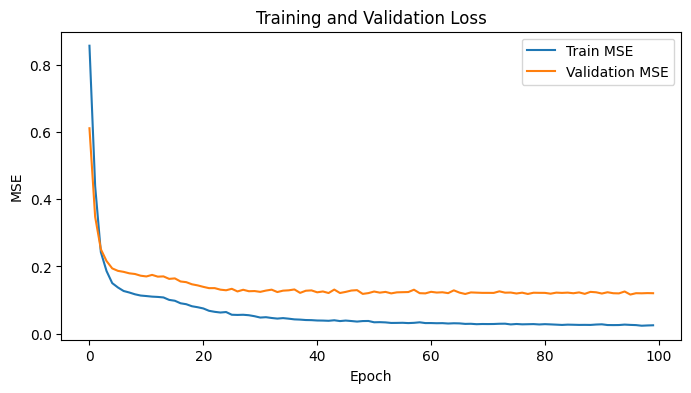

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_loss_list, label="Train MSE")
plt.plot(val_loss_list, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()